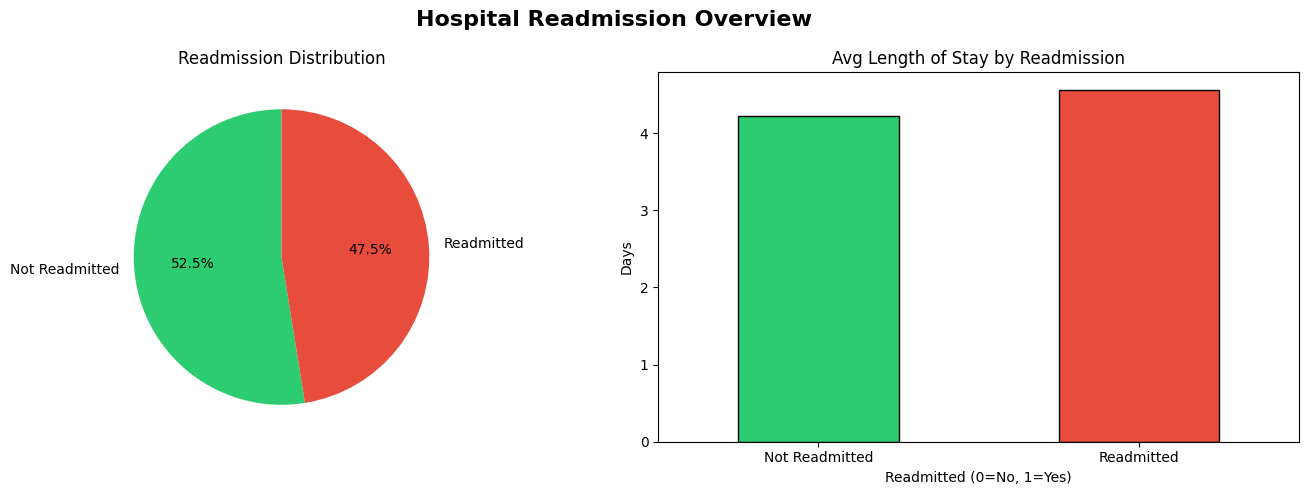

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = spark.table("workspace.default.gold_hospital_features").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hospital Readmission Overview", fontsize=16, fontweight='bold')

# Readmission Distribution
labels = ['Not Readmitted', 'Readmitted']
sizes = df['readmitted_binary'].value_counts().sort_index()
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title("Readmission Distribution")

# Avg Time in Hospital by Readmission
df.groupby('readmitted_binary')['time_in_hospital'].mean().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1].set_title("Avg Length of Stay by Readmission")
axes[1].set_xlabel("Readmitted (0=No, 1=Yes)")
axes[1].set_ylabel("Days")
axes[1].set_xticklabels(['Not Readmitted','Readmitted'], rotation=0)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart1_overview.png", dpi=150)
plt.show()

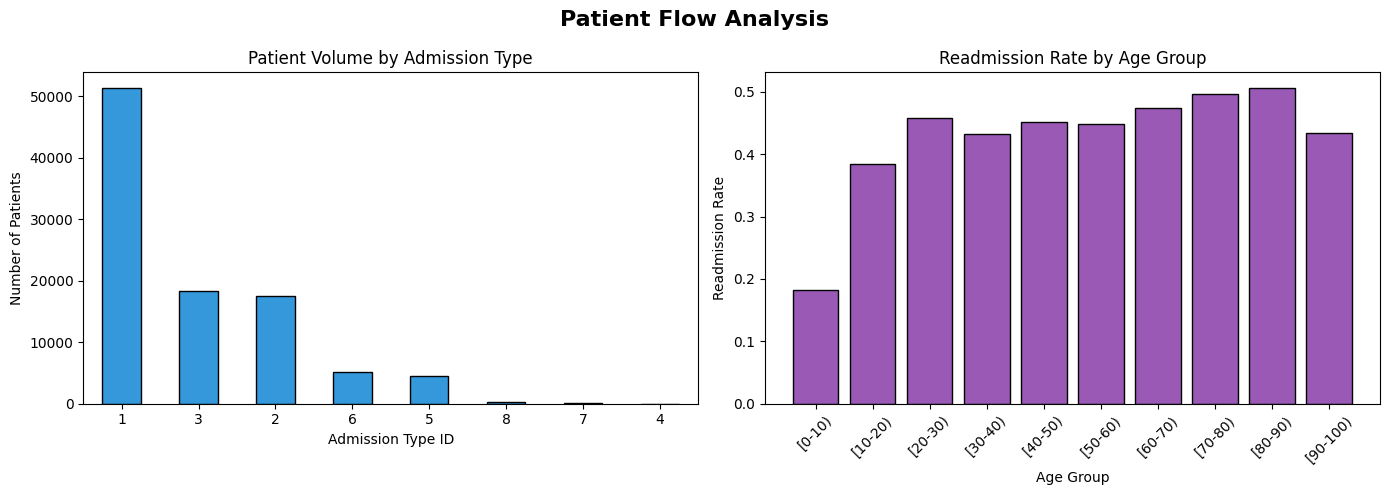

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Patient Flow Analysis", fontsize=16, fontweight='bold')

# Admissions by Type
df['admission_type_id'].value_counts().plot(
    kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title("Patient Volume by Admission Type")
axes[0].set_xlabel("Admission Type ID")
axes[0].set_ylabel("Number of Patients")
axes[0].tick_params(axis='x', rotation=0)

# Age group vs Readmission Rate
age_readmit = df.groupby('age')['readmitted_binary'].mean().reset_index()
age_readmit = age_readmit.sort_values('age')
axes[1].bar(age_readmit['age'], age_readmit['readmitted_binary'],
            color='#9b59b6', edgecolor='black')
axes[1].set_title("Readmission Rate by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Readmission Rate")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart2_patient_flow.png", dpi=150)
plt.show()

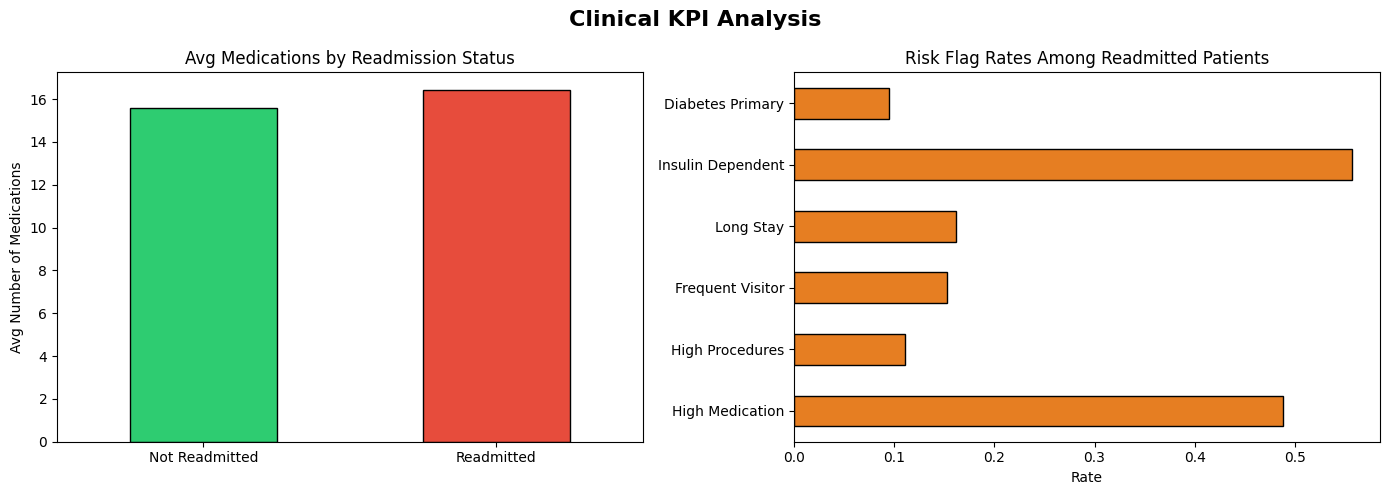

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Clinical KPI Analysis", fontsize=16, fontweight='bold')

# Medications vs Readmission
df.groupby('readmitted_binary')['num_medications'].mean().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title("Avg Medications by Readmission Status")
axes[0].set_xlabel("")
axes[0].set_xticklabels(['Not Readmitted','Readmitted'], rotation=0)
axes[0].set_ylabel("Avg Number of Medications")

# High Risk Flags
flags = ['high_medication_flag','high_procedures_flag',
         'frequent_visitor_flag','long_stay_flag',
         'insulin_flag','diabetes_primary_flag']
flag_rates = df[df['readmitted_binary']==1][flags].mean()
flag_rates.plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title("Risk Flag Rates Among Readmitted Patients")
axes[1].set_xlabel("Rate")
axes[1].set_yticklabels([
    'High Medication','High Procedures',
    'Frequent Visitor','Long Stay',
    'Insulin Dependent','Diabetes Primary'], rotation=0)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart3_kpis.png", dpi=150)
plt.show()

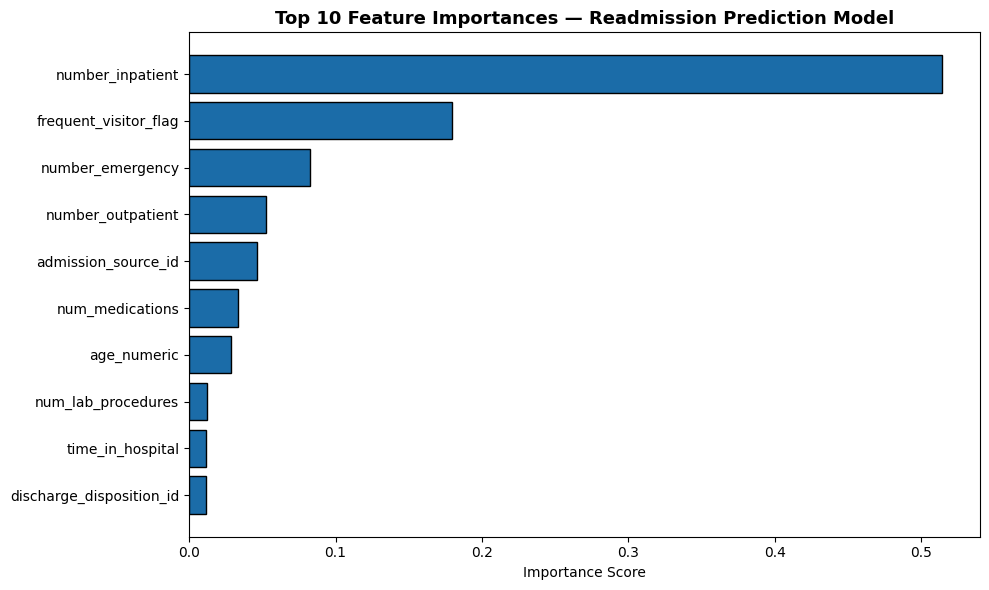

In [0]:
import numpy as np

feature_cols = [
    "age_numeric", "time_in_hospital", "num_lab_procedures",
    "num_procedures", "num_medications", "number_outpatient",
    "number_emergency", "number_inpatient", "admission_type_id",
    "discharge_disposition_id", "admission_source_id",
    "high_medication_flag", "high_procedures_flag",
    "frequent_visitor_flag", "long_stay_flag",
    "insulin_flag", "diabetes_primary_flag"
]

importance_values = [
    0.028739, 0.011573, 0.012007,
    0.006842, 0.033458, 0.052492,
    0.082786, 0.514289, 0.007061,
    0.011302, 0.046586,
    0.007246, 0.000525,
    0.179633, 0.000839,
    0.002152, 0.002468
]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance_values
}).sort_values("importance", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'],
        color='#1B6CA8', edgecolor='black')
ax.set_title("Top 10 Feature Importances — Readmission Prediction Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/Volumes/workspace/default/hospital_operations_ai/chart4_feature_importance.png", dpi=150)
plt.show()

In [0]:
kpis = {
    "Total Patients": len(df),
    "Readmission Rate (%)": round(df['readmitted_binary'].mean() * 100, 2),
    "Avg Length of Stay (days)": round(df['time_in_hospital'].mean(), 2),
    "Avg Medications per Patient": round(df['num_medications'].mean(), 2),
    "High Risk Patients (%)": round(df['frequent_visitor_flag'].mean() * 100, 2),
    "Model AUC (V2)": 0.6742,
    "Model Accuracy (V2)": 0.6287,
    "Model F1 Score (V2)": 0.6225
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"])
print("=" * 45)
print("   HOSPITAL OPERATIONS — KPI SUMMARY")
print("=" * 45)
print(kpi_df.to_string(index=False))
print("=" * 45)

   HOSPITAL OPERATIONS — KPI SUMMARY
                        KPI      Value
             Total Patients 97108.0000
       Readmission Rate (%)    47.4600
  Avg Length of Stay (days)     4.3800
Avg Medications per Patient    15.9800
     High Risk Patients (%)     9.9700
             Model AUC (V2)     0.6742
        Model Accuracy (V2)     0.6287
        Model F1 Score (V2)     0.6225
